# Multi-label classifier

Обучите модель для предсказания аттрибутов по фотографии на датасете [CelebA](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html)

**Задача**
Датасет содержит фотографий лиц. Каждая фотография характреризуется набором признаков: пол, возраст, улыбка ... всего 40 признаков

Нужно обучить модель которая будет предсказывать признаки по фотографии.
И оценить качество ее работы используя соответствующие метрики.


**Требования**:

- Разрешается и рекомендуется использовать предобученные модели.
- Будьте готовы ответить на любые вопросы по коду


# Порядок выполнения задания

Задание рекомендуется выполнять по шагам:

1. Познакомьтесь с данными
2. Выберите метрику для оценки результата
3. Проведите анализ, изучите существующие модели которые можно использовать для решения задачи
4. Проведите EDA, опишите особенности данных и проблемы которые они могут за собой повлечь
5. Подготовьте данные для обучения
6. Выберите baseline модель, оцените качество её работы на данном датасете.
7. Попробуйте улучшить значение метрики используя другую модель. Возможно обучив/дообучив ее.
8. Оцените быстродействие выбранной модели
9. Дайте оценку полученному результату.

## Анализ данных (EDA)

# Загрузка данных

In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import numpy as np

import time
from sklearn.metrics import f1_score, roc_auc_score

In [ ]:
!wget https://ml.gan4x4.ru/hse/cv/gan_celeba.zip
!unzip gan_celeba.zip -d celeba

In [ ]:
from torchvision.datasets import CelebA

# download = True cause an error with gdown
train_dataset = CelebA(root='/content', split='train', target_type='attr', download=False) #, transform=data_transform)

Total 41 attribute

In [ ]:
attr_names = train_dataset.attr_names[:-1] # last attr is empty
print("Attributes: ",", ".join(attr_names))
print(len(attr_names))

Attributes:  5_o_Clock_Shadow, Arched_Eyebrows, Attractive, Bags_Under_Eyes, Bald, Bangs, Big_Lips, Big_Nose, Black_Hair, Blond_Hair, Blurry, Brown_Hair, Bushy_Eyebrows, Chubby, Double_Chin, Eyeglasses, Goatee, Gray_Hair, Heavy_Makeup, High_Cheekbones, Male, Mouth_Slightly_Open, Mustache, Narrow_Eyes, No_Beard, Oval_Face, Pale_Skin, Pointy_Nose, Receding_Hairline, Rosy_Cheeks, Sideburns, Smiling, Straight_Hair, Wavy_Hair, Wearing_Earrings, Wearing_Hat, Wearing_Lipstick, Wearing_Necklace, Wearing_Necktie, Young
40


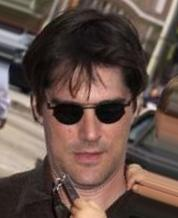

In [ ]:
train_dataset[52][0]

Look at pictures

In [ ]:
import matplotlib.pyplot as plt

# helper method
def show_images(ds, idx):
    fig, axes = plt.subplots(1, len(idx), figsize=(15, 5))
    for j, n in enumerate(idx):
        image, label = ds[n]
        axes[j].imshow(image)
        label_names = [ds.attr_names[i] for i in range(len(label)) if label[i] == 1]
        axes[j].set_title("\n".join(label_names))
        axes[j].axis('off')
    plt.show()

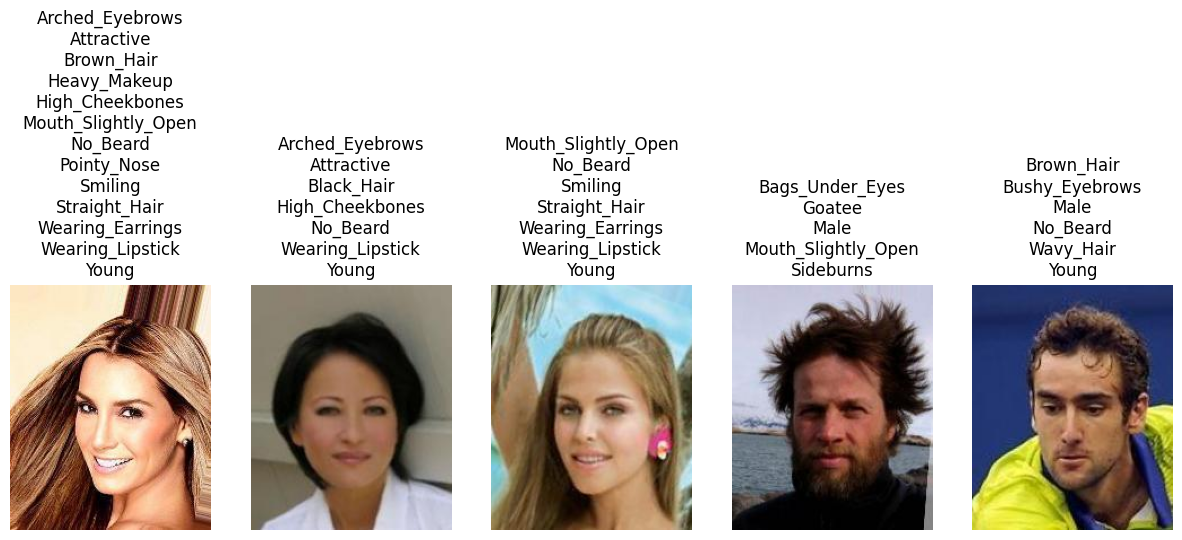

In [ ]:
show_images(train_dataset, [0,100,1000,10000,100000])

## EDA



Сначала проверим общую структуру данных внутри train_dataset. Проверим, что в каждом элементе есть изображение и метки классов (2 элемента внутри каждого), проверим что всего 40 меток, и что они равны только 0 или 1.

In [ ]:
def check_dataset_structure(ds, expected_num_attrs=40):
    for idx in range(len(ds)):
        item = ds[idx]
        assert len(item) == 2
        img, attrs = item
        attrs = torch.as_tensor(attrs)
        assert attrs.numel() == expected_num_attrs
        uniq = torch.unique(attrs)
        assert set(uniq.tolist()) == {0, 1} or set(uniq.tolist()) == {1} or set(uniq.tolist()) == {0}
    print(f"Структура внутри датасета валидна!")

In [ ]:
check_dataset_structure(train_dataset, expected_num_attrs=40)

attr_names = train_dataset.attr_names[:-1]
assert len(attr_names) == 40

Структура внутри датасета валидна!


Разделим на 3 выборки, тренировочную, валидационную и тестовую.

In [ ]:
idx_all = np.arange(len(train_dataset))
idx_train, idx_dev = train_test_split(idx_all, test_size=0.3, random_state=42, shuffle=True)
idx_val, idx_test = train_test_split(idx_dev, test_size=0.3, random_state=42, shuffle=True)

train_set = Subset(train_dataset, idx_train)
val_set   = Subset(train_dataset, idx_val)
test_set  = Subset(train_dataset, idx_test)

print(f"Размеры: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

Размеры: train=113939, val=34181, test=14650


Далее надо посмотреть, как разделяются '0' и '1' в трех выборках. Вдруг для какой-то метки в трейн попали все 1 или похожие ситуации.

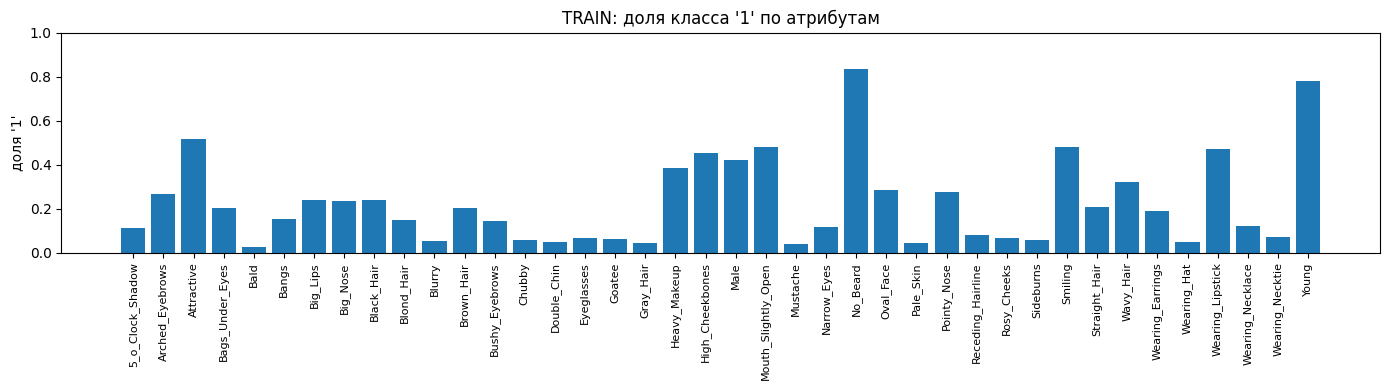

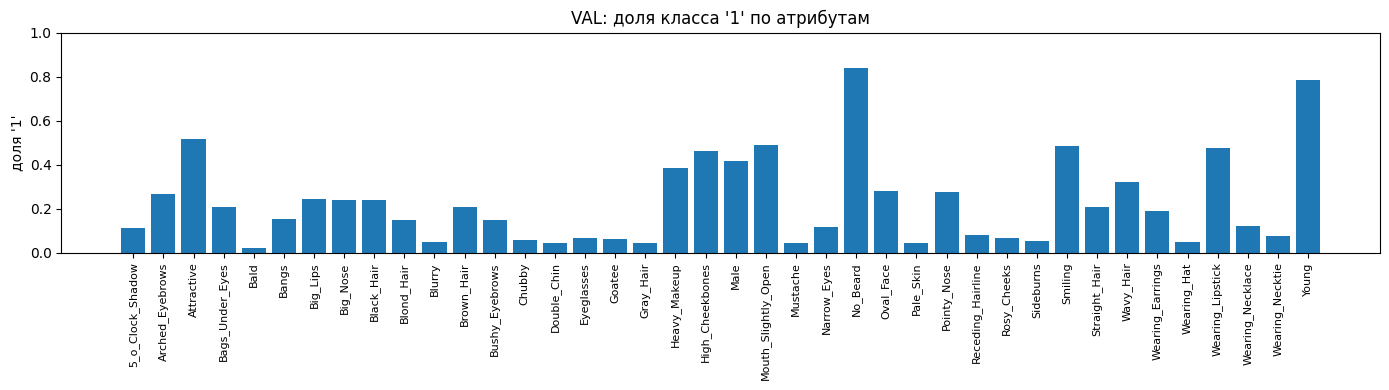

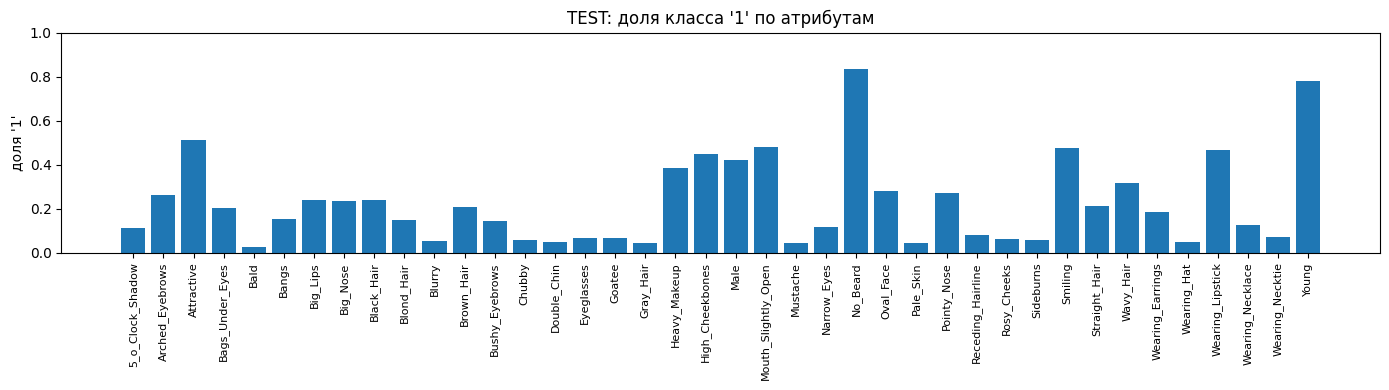

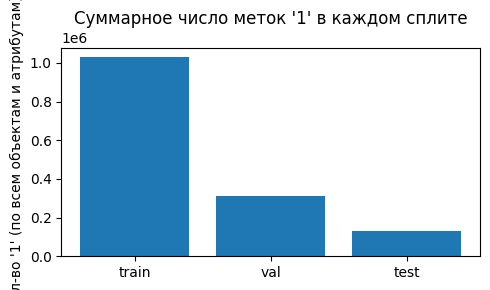

In [ ]:
Y = train_dataset.attr if isinstance(getattr(train_dataset, "attr", None), torch.Tensor) \
    else torch.stack([torch.as_tensor(a) for _, a in train_dataset])

Y01 = (Y == 1).to(torch.uint8)

def plot_pos_rate(idx_split, title):
    y = Y01[idx_split].float()
    pos_rate = y.mean(dim=0).cpu().numpy()
    plt.figure(figsize=(14, 4))
    plt.bar(np.arange(len(attr_names)), pos_rate)
    plt.title(f"{title}: доля класса '1' по атрибутам")
    plt.ylabel("доля '1'")
    plt.ylim(0, 1)
    plt.xticks(np.arange(len(attr_names)), attr_names, rotation=90, fontsize=8)
    plt.tight_layout(); plt.show()

plot_pos_rate(idx_train, "TRAIN")
plot_pos_rate(idx_val,   "VAL")
plot_pos_rate(idx_test,  "TEST")

def plot_total_ones():
    totals = [
        int(Y01[idx_train].sum()),
        int(Y01[idx_val].sum()),
        int(Y01[idx_test].sum()),
    ]
    labels = ["train", "val", "test"]
    plt.figure(figsize=(5, 3))
    plt.bar(labels, totals)
    plt.title("Суммарное число меток '1' в каждом сплите")
    plt.ylabel("кол-во '1' (по всем объектам и атрибутам)")
    plt.tight_layout()
    plt.show()

plot_total_ones()

Видно, что данные разделились очень равномерно по каждой метке.

# Метрики

Т.к решаем классификацию бинарную на нескольких метках, будем считать roc-auc и f1. Основная функция для этого - compute_metrics_simple, которая берет 2 массива: истинные и предсказанные значения. Возвращает метрики.

In [ ]:
def to_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    elif hasattr(x, "numpy"):
        x = x.numpy()
    return np.array(x)

def compute_metrics_simple(y_true, y_pred_logits_or_probs, threshold=0.5):
    y_true = to_numpy(y_true).astype(np.uint8)
    Z = to_numpy(y_pred_logits_or_probs).astype(np.float32)
    if Z.min() < 0 or Z.max() > 1:
        probs = 1.0 / (1.0 + np.exp(-Z))
    else:
        probs = np.clip(Z, 0.0, 1.0)

    y_pred = (probs >= threshold).astype(np.uint8)

    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    roc_values = []
    C = y_true.shape[1]
    for j in range(C):
        yj = y_true[:, j]; pj = probs[:, j]
        if yj.sum() > 0 and (len(yj) - yj.sum()) > 0:
            try:
                roc_values.append(roc_auc_score(yj, pj))
            except:
                pass
    macro_roc_auc = float(np.mean(roc_values)) if len(roc_values) else None

    return {
        "micro_F1": float(micro_f1),
        "macro_F1": float(macro_f1),
        "macro_ROC_AUC": macro_roc_auc,
        "valid_attrs_for_ROC": len(roc_values),
        "threshold": float(threshold),
    }


## Baseline

Сначала обучим модель resnet18 с замененной головой, у который выход - 40 меток. Сделаем небольшое шаманство с классом Wrap, так как у нас сейчас данные типа Subset с индексами, которые мы использовали для дата анализа. Далее обучим модель и оценим метрики.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class Wrap(Dataset):
    def __init__(self, base, transform=None):
        self.base = base
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, attr = self.base[i]
        if self.transform is not None:
            img = self.transform(img)
        y = (torch.as_tensor(attr) == 1).float()
        return img, y

train_ds = Wrap(train_set, train_tf)
val_ds   = Wrap(val_set,   eval_tf)
test_ds  = Wrap(test_set,  eval_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

print(f"Sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 40)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
epochs = 1

def eval_loader(loader):
    model.eval()
    ys, zs = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            z = model(x)
            ys.append(y.cpu())
            zs.append(z.cpu())
    return torch.cat(ys, 0), torch.cat(zs, 0)

best_val_micro = -1.0
best_state = None

LOG_EVERY = 200

for epoch in range(1, epochs + 1):
    model.train()
    run_loss = 0.0
    seen = 0
    total_batches = len(train_loader)
    print(f"\nEpoch {epoch} started: {total_batches} batches")
    for step, (x, y) in enumerate(train_loader, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        z = model(x)
        loss = criterion(z, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        run_loss += loss.item() * bs
        seen += bs

        if step % LOG_EVERY == 0 or step == total_batches:
            avg_loss = run_loss / max(1, seen)
            print(f"Epoch {epoch} | step {step}/{total_batches} | seen {seen}/{len(train_loader.dataset)} | loss {avg_loss}")

    train_loss = run_loss / len(train_loader.dataset)

    y_val, z_val = eval_loader(val_loader)
    metrics_val = compute_metrics_simple(y_val, z_val, threshold=0.5)

    print(f"Epoch {epoch} DONE | train_loss={train_loss} | "
          f"val micro_F1={metrics_val['micro_F1']} | "
          f"val macro_F1={metrics_val['macro_F1']} | "
          f"val macro_ROC_AUC={metrics_val['macro_ROC_AUC']}")

    if metrics_val["micro_F1"] > best_val_micro:
        best_val_micro = metrics_val["micro_F1"]

y_test, z_test = eval_loader(test_loader)
metrics_test = compute_metrics_simple(y_test, z_test, threshold=0.5)
print("\n=== Test metrics (baseline) ===")
for k, v in metrics_test.items():
    print(f"{k}: {v}")


device: cuda
Sizes: train=113939, val=34181, test=14650
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]



Epoch 1 started: 1781 batches
Epoch 1 | step 200/1781 | seen 12800/113939 | loss 0.2626
Epoch 1 | step 400/1781 | seen 25600/113939 | loss 0.2403
Epoch 1 | step 600/1781 | seen 38400/113939 | loss 0.2301
Epoch 1 | step 800/1781 | seen 51200/113939 | loss 0.2237
Epoch 1 | step 1000/1781 | seen 64000/113939 | loss 0.2196
Epoch 1 | step 1200/1781 | seen 76800/113939 | loss 0.2161
Epoch 1 | step 1400/1781 | seen 89600/113939 | loss 0.2135
Epoch 1 | step 1600/1781 | seen 102400/113939 | loss 0.2113
Epoch 1 | step 1781/1781 | seen 113939/113939 | loss 0.2098
Epoch 1 DONE | train_loss=0.2098 | val micro_F1=0.7962 | val macro_F1=0.6900 | val macro_ROC_AUC=0.9419912810499147


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



=== Test metrics (baseline) ===
micro_F1: 0.7952769634378256
macro_F1: 0.6907435662632847
macro_ROC_AUC: 0.9418975824738887
valid_attrs_for_ROC: 40
threshold: 0.5


## Решение

Тут код полностью дублируется. Возьмем более мощную модель - resnet50. Заморозим все слои, кроме последнего классификатора. Далее код совпадает. Посмотрим метрики

In [ ]:
print("device:", device)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 40)

for name, p in model.named_parameters():
    if not name.startswith("fc."):
        p.requires_grad = False

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
epochs = 1

best_val_micro, best_state = -1.0, None

for epoch in range(1, epochs + 1):
    model.train()
    run_loss, seen = 0.0, 0
    total_batches = len(train_loader)
    print(f"\nEpoch {epoch} started: {total_batches} batches")

    for step, (x, y) in enumerate(train_loader, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        run_loss += loss.item() * bs
        seen += bs

        if step % LOG_EVERY == 0 or step == total_batches:
            avg_loss = run_loss / max(1, seen)
            print(f"Epoch {epoch} | step {step}/{total_batches} | seen {seen}/{len(train_loader.dataset)} | loss {avg_loss}")

    y_val, z_val = eval_loader(val_loader)
    metrics_val = compute_metrics_simple(y_val, z_val, threshold=0.5)

    print(f"Epoch {epoch} DONE | train_loss={run_loss/max(1, seen)} | "
          f"val micro_F1={metrics_val['micro_F1']} | "
          f"val macro_F1={metrics_val['macro_F1']} | "
          f"val macro_ROC_AUC={metrics_val['macro_ROC_AUC']}")

    if metrics_val["micro_F1"] > best_val_micro:
        best_val_micro = metrics_val["micro_F1"]

y_test, z_test = eval_loader(test_loader)
metrics_test = compute_metrics_simple(y_test, z_test, threshold=0.5)
print("\n=== Test metrics (pretrained, frozen backbone) ===")
for k, v in metrics_test.items():
    print(f"{k}: {v}")

device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 44.0MB/s]



Epoch 1 started: 1781 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1 | step 200/1781 | seen 12800/113939 | loss 0.3693155689537525
Epoch 1 | step 400/1781 | seen 25600/113939 | loss 0.3409716189652681
Epoch 1 | step 600/1781 | seen 38400/113939 | loss 0.326278954744339
Epoch 1 | step 800/1781 | seen 51200/113939 | loss 0.3169924307614565
Epoch 1 | step 1000/1781 | seen 64000/113939 | loss 0.31025967183709147
Epoch 1 | step 1200/1781 | seen 76800/113939 | loss 0.3051604177430272
Epoch 1 | step 1400/1781 | seen 89600/113939 | loss 0.3011231338871377
Epoch 1 | step 1600/1781 | seen 102400/113939 | loss 0.29788987815380097
Epoch 1 | step 1781/1781 | seen 113939/113939 | loss 0.29553063044789596
Epoch 1 DONE | train_loss=0.29553063044789596 | val micro_F1=0.7083568732706043 | val macro_F1=0.5067002345306391 | val macro_ROC_AUC=0.8859351752388658


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



=== Test metrics (pretrained, frozen backbone) ===
micro_F1: 0.7071226688927214
macro_F1: 0.5103576702044508
macro_ROC_AUC: 0.8858423416850563
valid_attrs_for_ROC: 40
threshold: 0.5


## Оценка результата

Замерим среднее время предсказания 1 изображения последней модели.

In [ ]:
model.eval()

total_time = 0.0
total_imgs = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device, non_blocking=True)
        t0 = time.time()
        _ = model(x)
        total_time += time.time() - t0
        total_imgs += x.size(0)

ms_per_img = (total_time / max(1, total_imgs)) * 1000

print(f"Inference speed: {ms_per_img:.2f} ms/img")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Inference speed: 1.26 ms/img


### Итог

По всем метркиа resnet18, обучаемый с нуля, по всем метрика на тесте лучше предобученной resnet50 с дообучением. Не особо понимаю, с чем это может быть связано, может веса модели в начале должны лучше подогнаться под данные, чего не делается при заморозке.

По скорости: последняя модель предсказываем метки изображения со скоростью примерно 1.26 миллисекунд. То есть, если например так обрабатывать видео, то модель должна успевать.